# Baseline Logistic Regression Model

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

randomSeed = 1337

# load data
train_df = pd.read_csv('data/train_dataset.csv')
test_df = pd.read_csv('data/test_dataset.csv')

# extract X, Y
x_train = train_df.drop(columns=['Target_binary'])
y_train = train_df['Target_binary']

x_test = test_df.drop(columns=['Target_binary'])
y_test = test_df['Target_binary']


## Feature Engineering:

Created derived features to capture academic performance patterns:
- **pass rates**: the proportion of registered courses that were passed (approved / enrolled each semester); for each semester and overall (both)
- **average gpa**: tracked across both semesters 
- **academic improvement**: second sem grade - first sem grade
- **evaluation efficiency**: proportion of approved / evaluations (how many exams taken led to passing)
- **total academic activity**: raw totals of approved, enrolled, 


In [ ]:
# Feature Engineering Function
def engineer_features(df):
    df_eng = df.copy()
    
    # pass-rates (approved / enrolled) for each semester
    df_eng['1st_sem_pass_rate'] = np.where(
        df_eng['Curricular units 1st sem (enrolled)'] > 0,
        df_eng['Curricular units 1st sem (approved)'] / df_eng['Curricular units 1st sem (enrolled)'],
        0
    )
    
    df_eng['2nd_sem_pass_rate'] = np.where(
        df_eng['Curricular units 2nd sem (enrolled)'] > 0,
        df_eng['Curricular units 2nd sem (approved)'] / df_eng['Curricular units 2nd sem (enrolled)'],
        0
    )
    
    # overall pass rate across both semesters
    total_enrolled = df_eng['Curricular units 1st sem (enrolled)'] + df_eng['Curricular units 2nd sem (enrolled)']
    total_approved = df_eng['Curricular units 1st sem (approved)'] + df_eng['Curricular units 2nd sem (approved)']
    df_eng['overall_pass_rate'] = np.where(total_enrolled > 0, total_approved / total_enrolled, 0)
    
    # average grade
    df_eng['avg_grade'] = (df_eng['Curricular units 1st sem (grade)'] + 
                           df_eng['Curricular units 2nd sem (grade)']) / 2
    
    # academic improvement
    df_eng['grade_improvement'] = (df_eng['Curricular units 2nd sem (grade)'] - 
                                   df_eng['Curricular units 1st sem (grade)'])
    
    # eval efficiencies

    df_eng['1st_sem_eval_efficiency'] = np.where(
        df_eng['Curricular units 1st sem (evaluations)'] > 0,
        df_eng['Curricular units 1st sem (approved)'] / df_eng['Curricular units 1st sem (evaluations)'],
        0
    )
    
    df_eng['2nd_sem_eval_efficiency'] = np.where(
        df_eng['Curricular units 2nd sem (evaluations)'] > 0,
        df_eng['Curricular units 2nd sem (approved)'] / df_eng['Curricular units 2nd sem (evaluations)'],
        0
    )
    
    # academic activity
    df_eng['total_approved'] = total_approved
    df_eng['total_enrolled'] = total_enrolled
    df_eng['total_evaluations'] = (df_eng['Curricular units 1st sem (evaluations)'] + 
                                   df_eng['Curricular units 2nd sem (evaluations)'])
    
    
    return df_eng

# re-extract features
x_train_eng = train_df.drop(columns=['Target_binary'])
x_test_eng = test_df.drop(columns=['Target_binary'])

# apply feature engineering
x_train_eng = engineer_features(x_train_eng)
x_test_eng = engineer_features(x_test_eng)

print(f"Added {len(x_train_eng.columns) - 20} new features\n")

# display the new features
new_features = [col for col in x_train_eng.columns if col not in train_df.drop(columns=['Target_binary']).columns]
print("New features created:")
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

# update feature names and re-scale with new features
feature_names = x_train_eng.columns.tolist()

scaler_new = StandardScaler()
x_train = scaler_new.fit_transform(x_train_eng)
x_test  = scaler_new.transform(x_test_eng)



Original feature count: 20
After feature engineering: 30
Added 10 new features

New features created:
  1. 1st_sem_pass_rate
  2. 2nd_sem_pass_rate
  3. overall_pass_rate
  4. avg_grade
  5. grade_improvement
  6. 1st_sem_eval_efficiency
  7. 2nd_sem_eval_efficiency
  8. total_approved
  9. total_enrolled
  10. total_evaluations


## Baseline Model

Training a default Logistic Regression (no tuning) as a reference point before hyperparameter optimization.

In [3]:
# train baseline model with default parameters
baseline_lr = LogisticRegression(max_iter=1000, random_state=randomSeed)
baseline_lr.fit(x_train, y_train)

# baseline predictions
baseline_pred = baseline_lr.predict(x_test)
baseline_pred_proba = baseline_lr.predict_proba(x_test)[:, 1]

# baseline metrics
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_pred_proba)

print('BASELINE MODEL PERFORMANCE')
print(f'Accuracy:  {baseline_accuracy:.4f}')
print(f'Precision: {baseline_precision:.4f}')
print(f'Recall:    {baseline_recall:.4f}')
print(f'F1 Score:  {baseline_f1:.4f}')
print(f'ROC AUC:   {baseline_auc:.4f}')

BASELINE MODEL PERFORMANCE
Accuracy:  0.8681
Precision: 0.8477
Recall:    0.7191
F1 Score:  0.7781
ROC AUC:   0.9060


## Hyperparameter Tuning with GridSearchCV

We'll tune the following parameters:
- **C**: controls how much the model is penalized for large coefficients
- **penalty**: how the model penalizes large coefficients (L1, L2, elasticnet, none)
- **solver**: algorithm used to minimize loss (liblinear : fast for small data sets but doesnt support elasticnet, saga scales better on larger sets)
- **class_weight**: none => all samples are treated equally; 'balanced' : upweights the minority class

In [4]:
# define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

# init base model
base_lr = LogisticRegression(random_state=randomSeed)

# setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomSeed)

# grid search with cross-validation
print("Starting GridSearchCV")
print(f"Testing {len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver']) * len(param_grid['class_weight'])} combinations")

grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',  # optimizing for F1 score
    verbose=1,
    return_train_score=True
)

# fit the grid search
grid_search.fit(x_train, y_train)

print(f"\nBest F1 Score (CV): {grid_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")

for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Starting GridSearchCV
Testing 96 combinations
Fitting 5 folds for each of 96 candidates, totalling 480 fits


C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'pen


Best F1 Score (CV): 0.7970

Best Hyperparameters:
  C: 0.01
  class_weight: balanced
  max_iter: 1000
  penalty: l2
  solver: liblinear


C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\


Top 10 Parameter Combinations:

Rank 27:
  Parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Mean CV F1: 0.7970 (±0.0122)
  Train F1: 0.7957

Rank 30:
  Parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
  Mean CV F1: 0.7932 (±0.0122)
  Train F1: 0.7971

Rank 28:
  Parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
  Mean CV F1: 0.7932 (±0.0122)
  Train F1: 0.7971

Rank 42:
  Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
  Mean CV F1: 0.7898 (±0.0107)
  Train F1: 0.7919

Rank 35:
  Parameters: {'C': 0.1, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Mean CV F1: 0.7897 (±0.0283)
  Train F1: 0.7965

Rank 41:
  Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
  

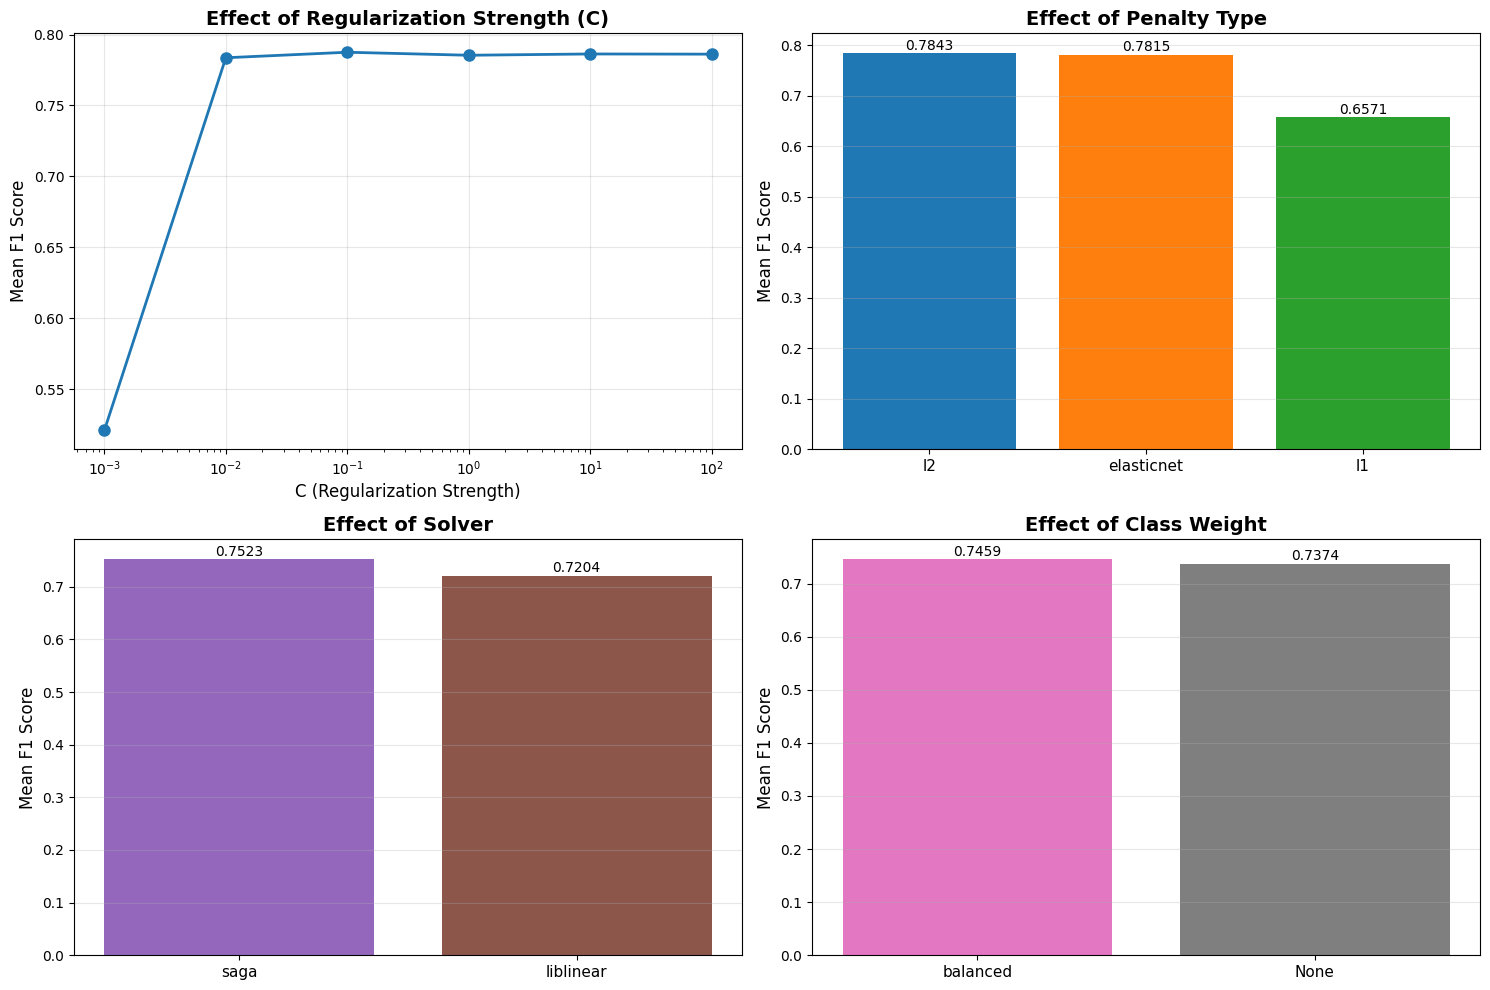

In [ ]:
# analyze top performing parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

print("\nTop 10 Parameter Combinations:")
top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10)
for idx, row in top_10.iterrows():
    print(f"\nRank {row.name + 1}:")
    print(f"  Parameters: {row['params']}")
    print(f"  Mean CV F1: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"  Train F1: {row['mean_train_score']:.4f}")

# visualize parameter importance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# C parameter effect
c_scores = results_df.groupby([param for param in results_df['params'].apply(lambda x: x['C'])])['mean_test_score'].mean()
axes[0, 0].plot(c_scores.index, c_scores.values, marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('C (Regularization Strength)', fontsize=12)
axes[0, 0].set_ylabel('Mean F1 Score', fontsize=12)
axes[0, 0].set_title('Effect of Regularization Strength (C)', fontsize=14, fontweight='bold')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

# penalty type effect
penalty_scores = results_df.groupby([param for param in results_df['params'].apply(lambda x: x['penalty'])])['mean_test_score'].mean().sort_values(ascending=False)
bars = axes[0, 1].bar(range(len(penalty_scores)), penalty_scores.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(penalty_scores)])
axes[0, 1].set_xticks(range(len(penalty_scores)))
axes[0, 1].set_xticklabels([str(x) for x in penalty_scores.index], fontsize=11)
axes[0, 1].set_ylabel('Mean F1 Score', fontsize=12)
axes[0, 1].set_title('Effect of Penalty Type', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar in bars:
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                    f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

# solver effect
solver_scores = results_df.groupby([param for param in results_df['params'].apply(lambda x: x['solver'])])['mean_test_score'].mean().sort_values(ascending=False)
bars = axes[1, 0].bar(range(len(solver_scores)), solver_scores.values, color=['#9467bd', '#8c564b'])
axes[1, 0].set_xticks(range(len(solver_scores)))
axes[1, 0].set_xticklabels(solver_scores.index, fontsize=11)
axes[1, 0].set_ylabel('Mean F1 Score', fontsize=12)
axes[1, 0].set_title('Effect of Solver', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar in bars:
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                    f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

# class_weight effect
class_weight_scores = results_df.groupby([param for param in results_df['params'].apply(lambda x: str(x['class_weight']))])['mean_test_score'].mean().sort_values(ascending=False)
bars = axes[1, 1].bar(range(len(class_weight_scores)), class_weight_scores.values, color=['#e377c2', '#7f7f7f'])
axes[1, 1].set_xticks(range(len(class_weight_scores)))
axes[1, 1].set_xticklabels([str(x) for x in class_weight_scores.index], fontsize=11)
axes[1, 1].set_ylabel('Mean F1 Score', fontsize=12)
axes[1, 1].set_title('Effect of Class Weight', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar in bars:
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                    f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Best Model Evaluation

In [14]:
# Get the best model
best_lr = grid_search.best_estimator_

# Make predictions
y_pred = best_lr.predict(x_test)
y_pred_proba = best_lr.predict_proba(x_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("BEST MODEL PERFORMANCE ON TEST SET")
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

BEST MODEL PERFORMANCE ON TEST SET

Accuracy:  0.8374
Precision: 0.7189
Recall:    0.8118
F1 Score:  0.7625
ROC AUC:   0.9071
              precision    recall  f1-score   support

     Class 0       0.90      0.85      0.88       751
     Class 1       0.72      0.81      0.76       356

    accuracy                           0.84      1107
   macro avg       0.81      0.83      0.82      1107
weighted avg       0.85      0.84      0.84      1107



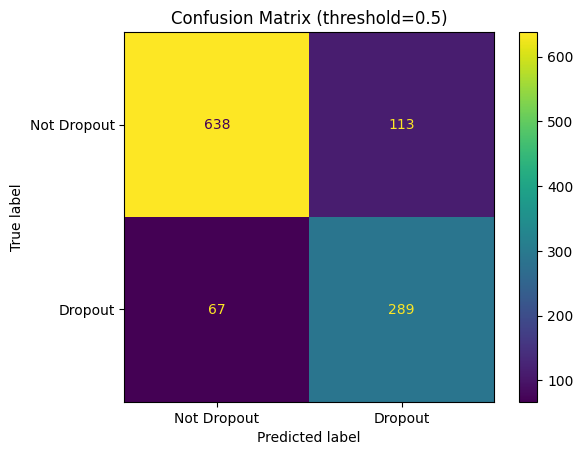


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

 Not Dropout       0.90      0.85      0.88       751
     Dropout       0.72      0.81      0.76       356

    accuracy                           0.84      1107
   macro avg       0.81      0.83      0.82      1107
weighted avg       0.85      0.84      0.84      1107



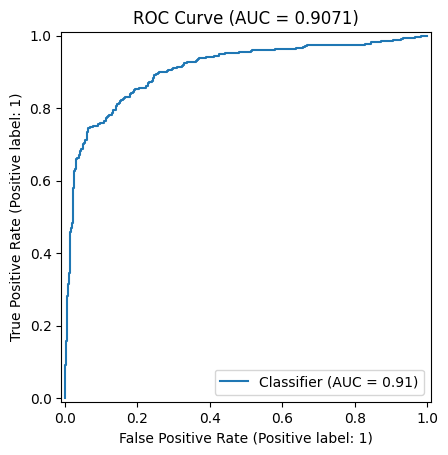

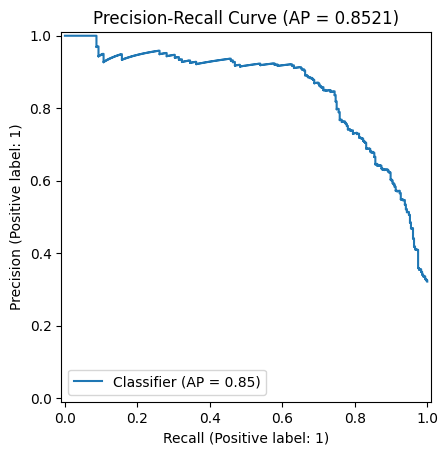


=== Additional Metrics (Test Set) ===
ROC AUC:           0.9071
Average Precision: 0.8521
Balanced Accuracy: 0.8307


In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Dropout", "Dropout"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

# classification report
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred, target_names=["Not Dropout", "Dropout"]))

# roc curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# precision-recall curve
avg_prec = average_precision_score(y_test, y_pred_proba)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)
plt.title(f"Precision-Recall Curve (AP = {avg_prec:.4f})")
plt.show()

# summary metrics
print("\n=== Additional Metrics (Test Set) ===")
print(f"ROC AUC:           {roc_auc:.4f}")
print(f"Average Precision: {avg_prec:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")


## Feature Importance Analysis

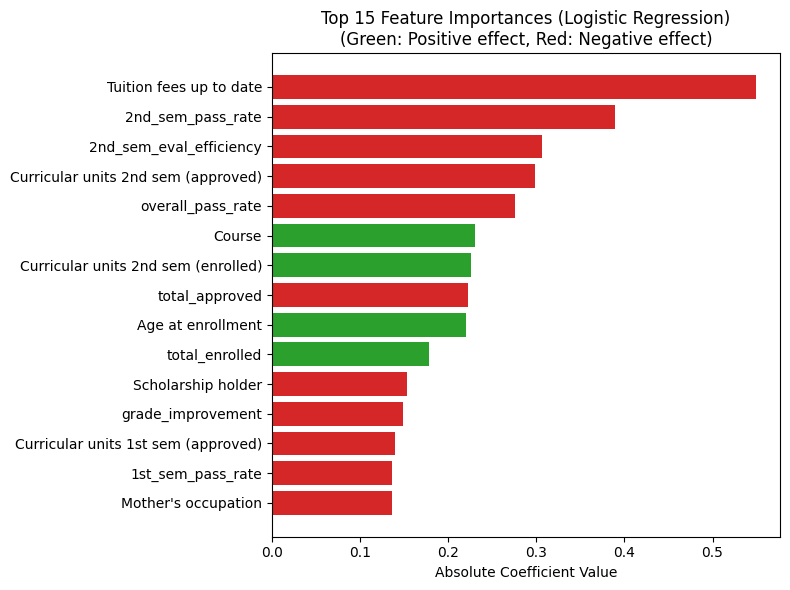

In [34]:
# extract feature coefficients

coefficients = best_lr.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# visualize top features (single plot, matching forest notebook style)
top_k = min(15, len(feature_names))
top_features = feature_importance.head(top_k)
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_features['Coefficient']]

plt.figure(figsize=(8, 6))
plt.barh(range(top_k), top_features['Abs_Coefficient'].values[::-1], color=colors[::-1])
plt.yticks(range(top_k), top_features['Feature'].values[::-1])
plt.xlabel("Absolute Coefficient Value")
plt.title(f"Top {top_k} Feature Importances (Logistic Regression)\n(Green: Positive effect, Red: Negative effect)")
plt.tight_layout()
plt.show()


## Feature Selection: Remove Low-Importance Features

Testing if removing features with low absolute coefficients improves generalization.

C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\cesar

 N Features  Accuracy  Precision   Recall  F1 Score  ROC AUC
         30  0.837398   0.718905 0.811798  0.762533 0.907079
         10  0.834688   0.712531 0.814607  0.760157 0.903999
         15  0.840108   0.720988 0.820225  0.767411 0.906666
         20  0.836495   0.717122 0.811798  0.761528 0.907187
         25  0.837398   0.717822 0.814607  0.763158 0.906690
         30  0.837398   0.718905 0.811798  0.762533 0.907079
Best result: 15 features (F1 Score improvement: +0.0049)


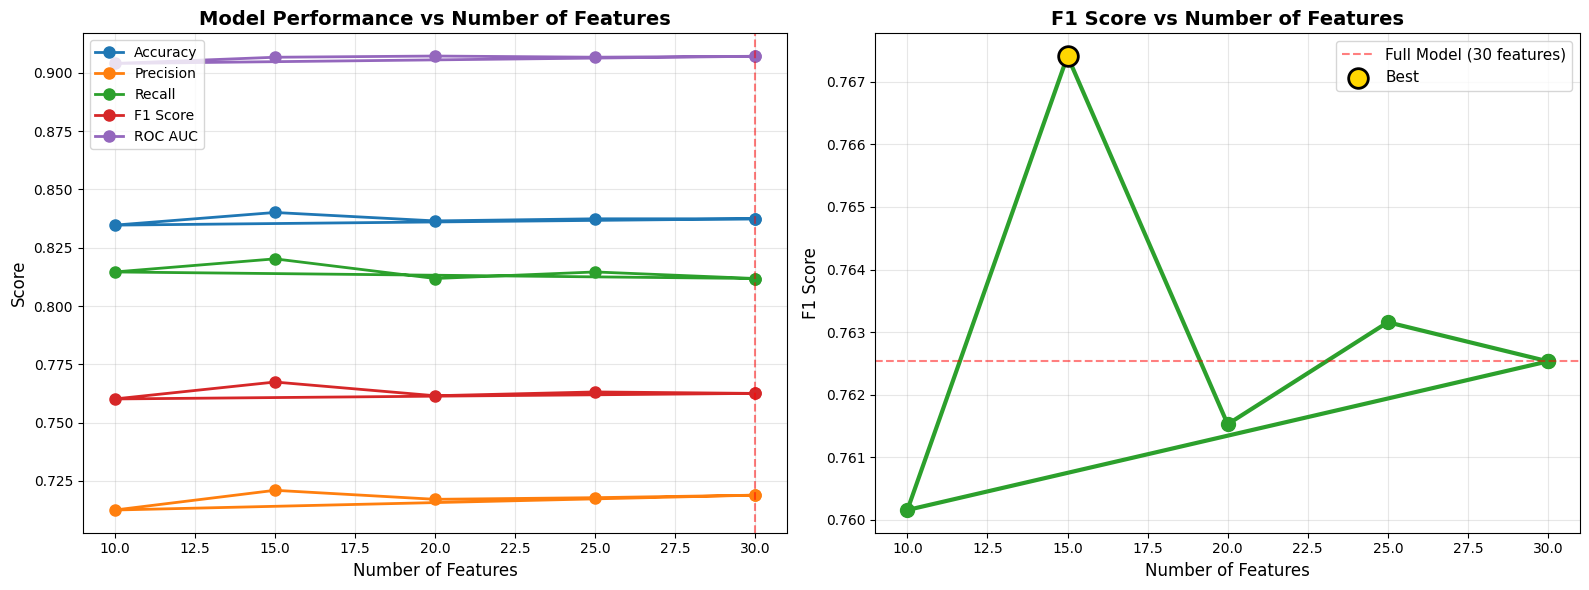

TOP 15 SELECTED FEATURES:
   1. Tuition fees up to date                  (Coefficient: -0.5491)
   2. 2nd_sem_pass_rate                        (Coefficient: -0.3891)
   3. 2nd_sem_eval_efficiency                  (Coefficient: -0.3067)
   4. Curricular units 2nd sem (approved)      (Coefficient: -0.2981)
   5. overall_pass_rate                        (Coefficient: -0.2761)
   6. Course                                   (Coefficient:  0.2301)
   7. Curricular units 2nd sem (enrolled)      (Coefficient:  0.2257)
   8. total_approved                           (Coefficient: -0.2228)
   9. Age at enrollment                        (Coefficient:  0.2201)
  10. total_enrolled                           (Coefficient:  0.1787)
  11. Scholarship holder                       (Coefficient: -0.1536)
  12. grade_improvement                        (Coefficient: -0.1490)
  13. Curricular units 1st sem (approved)      (Coefficient: -0.1399)
  14. 1st_sem_pass_rate                        (Coefficient: -0.

In [36]:
# try different number of features
feature_selection_results = []

for n_features in [10, 15, 20, 25, 30]:
    # select top n features by absolute coefficient
    top_features = feature_importance.head(n_features)['Feature'].tolist()
    top_feature_indices = [feature_names.index(f) for f in top_features]
    
    # subset the data
    x_train_selected = x_train[:, top_feature_indices]
    x_test_selected = x_test[:, top_feature_indices]
    
    # train model with selected features
    model = LogisticRegression(
        C=grid_search.best_params_['C'],
        penalty=grid_search.best_params_['penalty'],
        solver=grid_search.best_params_['solver'],
        class_weight=grid_search.best_params_['class_weight'],
        max_iter=1000,
        random_state=randomSeed
    )
    model.fit(x_train_selected, y_train)
    
    # evaluate
    y_pred_selected = model.predict(x_test_selected)
    y_pred_proba_selected = model.predict_proba(x_test_selected)[:, 1]
    
    feature_selection_results.append({
        'N Features': n_features,
        'Accuracy': accuracy_score(y_test, y_pred_selected),
        'Precision': precision_score(y_test, y_pred_selected),
        'Recall': recall_score(y_test, y_pred_selected),
        'F1 Score': f1_score(y_test, y_pred_selected),
        'ROC AUC': roc_auc_score(y_test, y_pred_proba_selected)
    })

# create comparison DataFrame
fs_comparison = pd.DataFrame(feature_selection_results)

# add full model results for comparison
fs_comparison = pd.concat([
    pd.DataFrame([{
        'N Features': len(feature_names),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }]),
    fs_comparison
]).reset_index(drop=True)

print(fs_comparison.to_string(index=False))

# find best configuration
best_idx = fs_comparison['F1 Score'].idxmax()
best_n = fs_comparison.loc[best_idx, 'N Features']
improvement = fs_comparison.loc[best_idx, 'F1 Score'] - fs_comparison.loc[0, 'F1 Score']

if improvement > 0:
    print(f"Best result: {int(best_n)} features (F1 Score improvement: +{improvement:.4f})")
else:
    print(f"Full feature set performs best (F1 Score: {fs_comparison.loc[0, 'F1 Score']:.4f})")

# visualize feature selection impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot all metrics vs number of features
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
for metric in metrics:
    axes[0].plot(fs_comparison['N Features'], fs_comparison[metric], 
                marker='o', linewidth=2, markersize=8, label=metric)

axes[0].set_xlabel('Number of Features', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance vs Number of Features', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=len(feature_names), color='red', linestyle='--', alpha=0.5, label='Full Model')

# f1 score focused plot
axes[1].plot(fs_comparison['N Features'], fs_comparison['F1 Score'], 
            marker='o', linewidth=3, markersize=10, color='#2ca02c')
axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('F1 Score vs Number of Features', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=fs_comparison.loc[0, 'F1 Score'], color='red', linestyle='--', 
               alpha=0.5, label=f'Full Model ({len(feature_names)} features)')

# hilight best point
if best_idx > 0:
    axes[1].scatter([best_n], [fs_comparison.loc[best_idx, 'F1 Score']], 
                   s=200, color='gold', edgecolors='black', linewidths=2, 
                   zorder=5, label='Best')

axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# if fs inc performance => show which features were selected
if improvement > 0:
    print(f"TOP {int(best_n)} SELECTED FEATURES:")
    print("="*20)
    for i, feat in enumerate(feature_importance.head(int(best_n))['Feature'], 1):
        coef = feature_importance[feature_importance['Feature'] == feat]['Coefficient'].values[0]
        print(f"  {i:2d}. {feat:40s} (Coefficient: {coef:7.4f})")

## Threshold Optimization for Better F1 Score
Since missing a dropout is costly, we'll find the optimal threshold to maximize F1 Score.

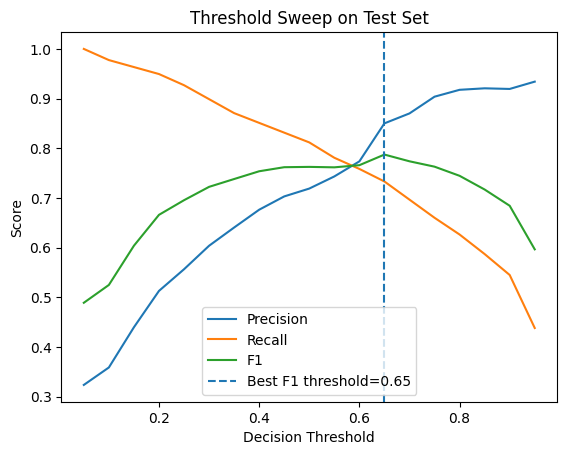


Best F1 on test set occurs at threshold ≈ 0.65 with F1 = 0.7873


In [37]:
# how precision/recall/f1 change with cutoff
thresholds = np.linspace(0.05, 0.95, 19)

def prf_at_threshold(t):
    pred_t = (y_pred_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return precision, recall, f1

precisions, recalls, f1s = [], [], []
for t in thresholds:
    p, r, f = prf_at_threshold(t)
    precisions.append(p); recalls.append(r); f1s.append(f)

best_idx = int(np.argmax(f1s))
best_t   = float(thresholds[best_idx])

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls,    label="Recall")
plt.plot(thresholds, f1s,        label="F1")
plt.axvline(best_t, linestyle="--", label=f"Best F1 threshold={best_t:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep on Test Set")
plt.legend()
plt.show()

print(f"\nBest F1 on test set occurs at threshold ≈ {best_t:.2f} with F1 = {f1s[best_idx]:.4f}")


## Model Comparison: Baseline vs Optimized

PERFORMANCE COMPARISON
   Metric  Baseline  Optimized  Improvement  Improvement %
 Accuracy  0.868112   0.837398    -0.030714          -3.54
Precision  0.847682   0.718905    -0.128777         -15.19
   Recall  0.719101   0.811798     0.092697          12.89
 F1 Score  0.778116   0.762533    -0.015583          -2.00
  ROC AUC  0.905968   0.907079     0.001111           0.12


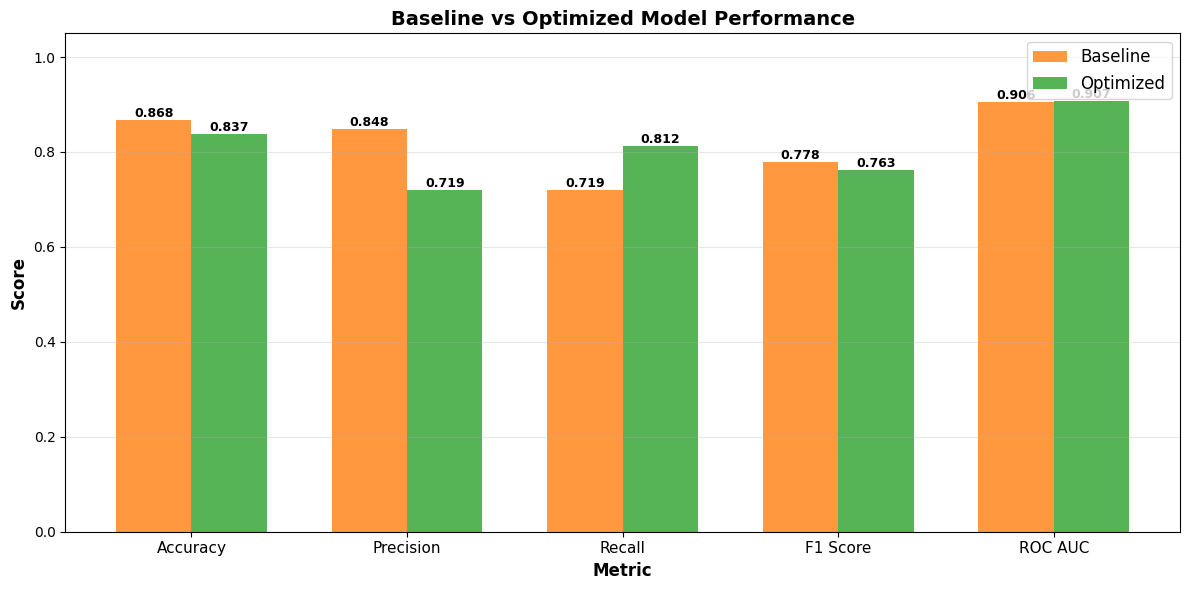

In [29]:
# create comparison dataframe
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Baseline': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_auc],
    'Optimized': [accuracy, precision, recall, f1, roc_auc]
})
comparison['Improvement'] = comparison['Optimized'] - comparison['Baseline']
comparison['Improvement %'] = (comparison['Improvement'] / comparison['Baseline'] * 100).round(2)

print('PERFORMANCE COMPARISON')
print(comparison.to_string(index=False))

# visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Baseline'], width, label='Baseline', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison['Optimized'], width, label='Optimized', color='#2ca02c', alpha=0.8)

ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs Optimized Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], fontsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## Feature Engineering Impact

Comparing the best model trained on the original 20 features against the full 30 engineered features to isolate the impact of feature engineering.

C:\Users\cesar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


FEATURE ENGINEERING IMPACT
   Metric  20 Features (original)  30 Features (engineered)  Difference
 Accuracy                0.838302                  0.837398   -0.000903
Precision                0.729870                  0.718905   -0.010965
   Recall                0.789326                  0.811798    0.022472
 F1 Score                0.758435                  0.762533    0.004098
  ROC AUC                0.903470                  0.907079    0.003609


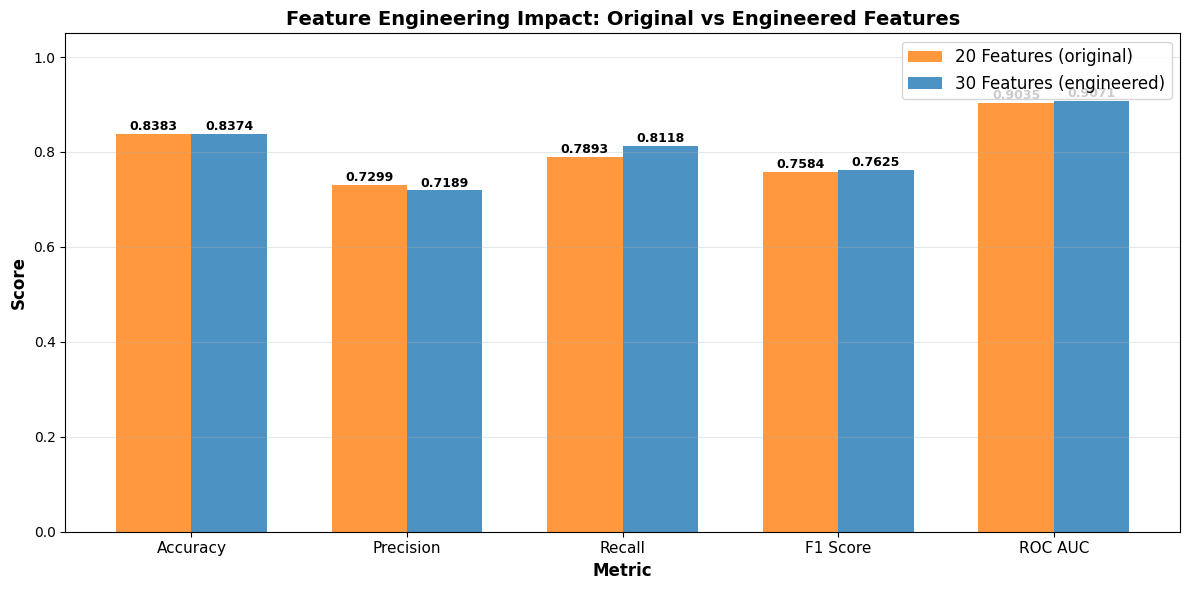

In [39]:
# train on original 20 features only (no engineered features), using best hyperparameters
original_features = train_df.drop(columns=['Target_binary']).columns.tolist()

x_train_orig = train_df[original_features].values
x_test_orig  = test_df[original_features].values

scaler_orig = StandardScaler()
x_train_orig = scaler_orig.fit_transform(x_train_orig)
x_test_orig  = scaler_orig.transform(x_test_orig)

model_orig = LogisticRegression(
    C=grid_search.best_params_['C'],
    penalty=grid_search.best_params_['penalty'],
    solver=grid_search.best_params_['solver'],
    class_weight=grid_search.best_params_['class_weight'],
    max_iter=1000,
    random_state=randomSeed
)
model_orig.fit(x_train_orig, y_train)
y_pred_orig       = model_orig.predict(x_test_orig)
y_pred_proba_orig = model_orig.predict_proba(x_test_orig)[:, 1]

# metrics for both models
metrics_comparison = pd.DataFrame({
    'Metric':    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    '20 Features (original)': [
        accuracy_score(y_test, y_pred_orig),
        precision_score(y_test, y_pred_orig),
        recall_score(y_test, y_pred_orig),
        f1_score(y_test, y_pred_orig),
        roc_auc_score(y_test, y_pred_proba_orig)
    ],
    '30 Features (engineered)': [accuracy, precision, recall, f1, roc_auc]
})
metrics_comparison['Difference'] = metrics_comparison['30 Features (engineered)'] - metrics_comparison['20 Features (original)']

print("FEATURE ENGINEERING IMPACT")
print(metrics_comparison.to_string(index=False))

# visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_comparison['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_comparison['20 Features (original)'],  width, label='20 Features (original)',   color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, metrics_comparison['30 Features (engineered)'], width, label='30 Features (engineered)', color='#1f77b4', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Engineering Impact: Original vs Engineered Features', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison['Metric'], fontsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()